Number of mice: 39
Pearson correlation (r): 0.167
P-value: 0.3101


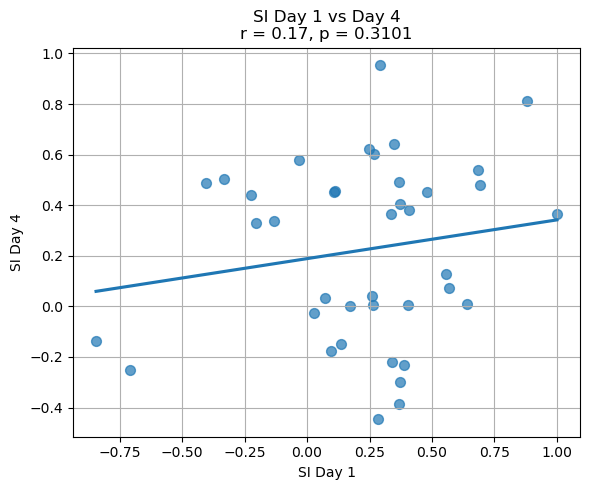

In [9]:
import pandas as pd
from scipy.stats import pearsonr

# Step 1: Load the Excel file
file_path = r"C:\Users\sjs93\OneDrive - University of Florida\SI_opto_1_2.xlsx"  # Make sure the file is in your working directory
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Step 2: Extract Day 1 and Day 4 SI columns
si_day1 = df['SI Day 1']
si_day4 = df['Si Day 4']

# Step 3: Drop missing values
si_data = pd.DataFrame({'Day 1': si_day1, 'Day 4': si_day4}).dropna()

# Step 4: Run Pearson correlation
r_value, p_value = pearsonr(si_data['Day 1'], si_data['Day 4'])

# Step 5: Print results
print(f"Number of mice: {len(si_data)}")
print(f"Pearson correlation (r): {r_value:.3f}")
print(f"P-value: {p_value:.4f}")

# Step 5: Plot
plt.figure(figsize=(6, 5))
sns.regplot(x='Day 1', y='Day 4', data=si_data, ci=None, scatter_kws={'s': 50, 'alpha': 0.7})
plt.title(f"SI Day 1 vs Day 4\nr = {r_value:.2f}, p = {p_value:.4f}")
plt.xlabel("SI Day 1")
plt.ylabel("SI Day 4")
plt.grid(True)
plt.tight_layout()
plt.show()

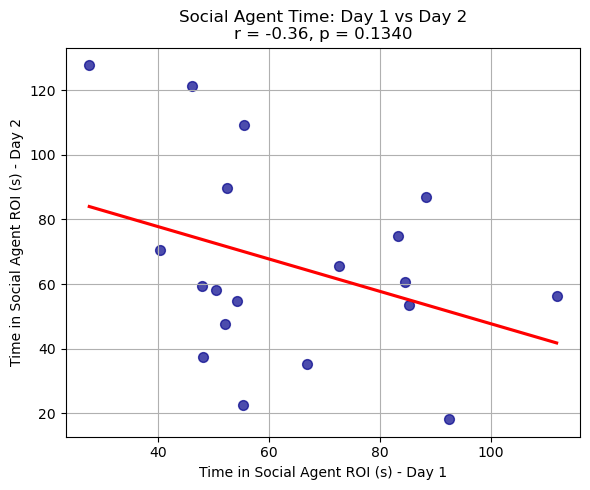

In [25]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Load Excel file
file_path = r"C:\Users\sjs93\OneDrive - University of Florida\SI_opto_1_2.xlsx"
df = pd.read_excel(file_path, sheet_name='sheet1')

# Use correct columns for Day 1 and Day 4 social time
time_day1 = df['social agent ROI']
time_day4 = df['social agent ROI.1']

# Drop missing values
time_data = pd.DataFrame({'Day 1': time_day1, 'Day 2': time_day4}).dropna()

# Pearson correlation
r_value, p_value = pearsonr(time_data['Day 1'], time_data['Day 2'])

# Plot
plt.figure(figsize=(6, 5))
sns.regplot(x='Day 1', y='Day 2', data=time_data, ci=None,
            scatter_kws={'s': 50, 'alpha': 0.7, 'color': 'darkblue'},
            line_kws={'color': 'red'})
plt.title(f"Social Agent Time: Day 1 vs Day 2\nr = {r_value:.2f}, p = {p_value:.4f}")
plt.xlabel("Time in Social Agent ROI (s) - Day 1")
plt.ylabel("Time in Social Agent ROI (s) - Day 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
print(f"n = {len(time_data)}, r = {r_value:.3f}, p = {p_value:.4f}")


n = 19, r = -0.357, p = 0.1340


In [54]:
import pandas as pd

# Load pilot 1
pilot1 = pd.read_excel(r"C:\Users\sjs93\OneDrive - University of Florida\soc_opto_pilot1_c57.xlsx")
pilot1["Subject_ID"] = "P1_" + pilot1["animal"].astype(str)

# Load pilot 2 cm and lf separately
pilot2_cm = pd.read_excel(r"C:\Users\sjs93\OneDrive - University of Florida\soc_opto2_redo_cm_mPFC_NAc_ArchT.xlsx")
pilot2_cm["Subject_ID"] = "P2_" + pilot2_cm["Animal"].astype(str)

pilot2_lf = pd.read_excel(r"C:\Users\sjs93\Downloads\soc_opto2_redo_lf_mPFC_NAc_ArchT.xlsx")
pilot2_lf["Subject_ID"] = "P2_" + pilot2_lf["Animal"].astype(str)


In [55]:
print(pilot1[['animal', 'Subject_ID']].head())
print(pilot2_cm[['Animal', 'Subject_ID']].head())
print(pilot2_lf[['Animal', 'Subject_ID']].head())


   animal Subject_ID
0     4.2     P1_4.2
1     1.1     P1_1.1
2     1.3     P1_1.3
3     6.2     P1_6.2
4     4.3     P1_4.3
   Animal Subject_ID
0     7.1     P2_7.1
1     7.2     P2_7.2
2     7.3     P2_7.3
3     1.1     P2_1.1
4     1.2     P2_1.2
   Animal Subject_ID
0     4.1     P2_4.1
1     4.2     P2_4.2
2     4.3     P2_4.3
3     6.1     P2_6.1
4     6.2     P2_6.2


In [61]:
# Drop columns with NaN or columns starting with 'Unnamed'
pilot2_lf = pilot2_lf.loc[:, pilot2_lf.columns.notnull()]  # remove NaN column names
pilot2_lf = pilot2_lf.loc[:, ~pilot2_lf.columns.str.startswith('Unnamed')]  # remove Unnamed cols

# Then check again
print("pilot2_lf columns after cleanup:", pilot2_lf.columns.tolist())
print("pilot2_lf columns unique?", pilot2_lf.columns.is_unique)


pilot2_lf columns after cleanup: ['Day', 'Test', 'Animal', 'Treatment', 'Social_ROI', 'NonSocial_ROI', 'Whole-Chamber : time (s)', 'WC social : time (s)', 'WC non social : time (s)', 'Sex', 'notes', 'AnyMaze File Name', 'Condition', 'Subject_ID', 'Pilot']
pilot2_lf columns unique? True


In [59]:
import pandas as pd

# Load pilot1 data
pilot1 = pd.read_excel(r"C:\Users\sjs93\OneDrive - University of Florida\soc_opto_pilot1_c57.xlsx")

# Strip spaces from all column names to avoid confusion
pilot1.columns = pilot1.columns.str.strip()

# Rename and standardize columns for pilot1
pilot1.rename(columns={
    'ACT day': 'Day',               # Use ACT day as Day
    'fam level': 'Condition',       # Rename fam level to Condition
    'animal': 'Animal',
    'social agent ROI': 'Social_ROI',
    'empty cup ROI': 'NonSocial_ROI'
}, inplace=True)

# Make sure Condition is uppercase and strip spaces if any
pilot1['Condition'] = pilot1['Condition'].str.upper().str.strip()

# Create unique Subject_ID
pilot1['Subject_ID'] = 'P1_' + pilot1['Animal'].astype(str)

# Add Pilot column for reference
pilot1['Pilot'] = 'P1'


# Load pilot2 cm data
pilot2_cm = pd.read_excel(r"C:\Users\sjs93\OneDrive - University of Florida\soc_opto2_redo_cm_mPFC_NAc_ArchT.xlsx")

# Strip spaces from columns
pilot2_cm.columns = pilot2_cm.columns.str.strip()

# Rename and standardize columns for pilot2_cm
pilot2_cm.rename(columns={
    'Day': 'Day',
    'Animal': 'Animal',
    'Social ROI : time investigating (s)': 'Social_ROI',
    'Non social ROI : time investigating (s)': 'NonSocial_ROI'
}, inplace=True)

# Set Condition column explicitly for pilot2_cm (cagemate condition)
pilot2_cm['Condition'] = 'CM'

# Create unique Subject_ID
pilot2_cm['Subject_ID'] = 'P2_' + pilot2_cm['Animal'].astype(str)

# Add Pilot column
pilot2_cm['Pilot'] = 'P2'


# Load pilot2 lf data
pilot2_lf = pd.read_excel(r"C:\Users\sjs93\Downloads\soc_opto2_redo_lf_mPFC_NAc_ArchT.xlsx")

# Strip spaces from columns
pilot2_lf.columns = pilot2_lf.columns.str.strip()

# Rename and standardize columns for pilot2_lf
pilot2_lf.rename(columns={
    'Day': 'Day',
    'Animal': 'Animal',
    'Social ROI : time investigating (s)': 'Social_ROI',
    'Non social ROI : time investigating (s)': 'NonSocial_ROI'
}, inplace=True)

# Set Condition column explicitly for pilot2_lf (low-familiarity condition)
pilot2_lf['Condition'] = 'LF'

# Create unique Subject_ID
pilot2_lf['Subject_ID'] = 'P2_' + pilot2_lf['Animal'].astype(str)

# Add Pilot column
pilot2_lf['Pilot'] = 'P2'


# Now combine all three dataframes into one master dataframe
combined_df = pd.concat([pilot1, pilot2_cm, pilot2_lf], ignore_index=True, sort=False)

# Optional: Check combined columns and dataframe shape
print(combined_df.columns)
print(f"Combined dataframe shape: {combined_df.shape}")


InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [60]:
print("pilot1 columns:", pilot1.columns.tolist())
print("pilot2_cm columns:", pilot2_cm.columns.tolist())
print("pilot2_lf columns:", pilot2_lf.columns.tolist())

print("pilot1 columns unique?", pilot1.columns.is_unique)
print("pilot2_cm columns unique?", pilot2_cm.columns.is_unique)
print("pilot2_lf columns unique?", pilot2_lf.columns.is_unique)


pilot1 columns: ['Day', 'day', 'sex', 'Animal', 'Condition', 'group', 'Social_ROI', 'NonSocial_ROI', 'whole chamber', 'whole chamber social agent', 'whole chamber empty cup', 'Subject_ID', 'Pilot']
pilot2_cm columns: ['Day', 'Test', 'Animal', 'Treatment', 'Social_ROI', 'NonSocial_ROI', 'Whole Chamber time', 'WC freezing episodes', 'WC time freezing', 'WC social : time (s)', 'WC non social : time (s)', 'Sex', 'notes', 'AnyMaze File Name', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'additional notes', 'Condition', 'Subject_ID', 'Pilot']
pilot2_lf columns: ['Day', 'Test', 'Animal', 'Treatment', 'Social_ROI', 'NonSocial_ROI', 'Whole-Chamber : time (s)', 'WC social : time (s)', 'WC non social : time (s)', 'Sex', 'notes', 'AnyMaze File Name', 'Unnamed: 12', 'Unnamed: 13', nan, nan, 'Condition', 'Subject_ID', 'Pilot']
pilot1 columns unique? True
pilot2_cm columns unique? True
pilot2_lf columns unique? False


In [56]:
# For pilot1
pilot1.rename(columns={
    'day': 'Day',
    'animal': 'Animal',
    'fam level': 'Condition',
    'social agent ROI': 'Social_ROI',
    'empty cup ROI': 'NonSocial_ROI'
}, inplace=True)

pilot1['Subject_ID'] = 'P1_' + pilot1['Animal'].astype(str)
pilot1['Condition'] = pilot1['Condition'].str.upper()  # Make sure LF and CM are uppercase

# For pilot2_cm
pilot2_cm.rename(columns={
    'Day': 'Day',
    'Animal': 'Animal',
    'Social ROI : time investigating (s)': 'Social_ROI',
    'Non social ROI : time investigating (s)': 'NonSocial_ROI'
}, inplace=True)

pilot2_cm['Subject_ID'] = 'P2_' + pilot2_cm['Animal'].astype(str)
pilot2_cm['Condition'] = 'CM'

# For pilot2_lf
pilot2_lf.rename(columns={
    'Day': 'Day',
    'Animal': 'Animal',
    'Social ROI : time investigating (s)': 'Social_ROI',
    'Non social ROI : time investigating (s)': 'NonSocial_ROI'
}, inplace=True)

pilot2_lf['Subject_ID'] = 'P2_' + pilot2_lf['Animal'].astype(str)
pilot2_lf['Condition'] = 'LF'

# Combine
combined_df = pd.concat([pilot1, pilot2_cm, pilot2_lf], ignore_index=True)


KeyError: 'Condition'

In [49]:
import pandas as pd

# --- Load Pilot 1 ---
pilot1 = pd.read_excel(r"C:\Users\sjs93\OneDrive - University of Florida\soc_opto_pilot1_c57.xlsx")
pilot1.columns = pilot1.columns.str.strip().str.lower().str.replace(" ", "_")
pilot1["subject_id"] = "P1_" + pilot1["animal"].astype(str)
pilot1["pilot"] = "P1"
pilot1["condition"] = pilot1["fam_level"].str.upper()

# --- Load Pilot 2 CM ---
pilot2_cm = pd.read_excel(r"C:\Users\sjs93\OneDrive - University of Florida\soc_opto2_redo_cm_mPFC_NAc_ArchT.xlsx")
pilot2_cm.columns = pilot2_cm.columns.str.strip().str.lower().str.replace(" ", "_")
pilot2_cm["subject_id"] = "P2_" + pilot2_cm["animal"].astype(str)
pilot2_cm["pilot"] = "P2"
pilot2_cm["condition"] = "CM"

# --- Load Pilot 2 LF ---
pilot2_lf = pd.read_excel(r"C:\Users\sjs93\Downloads\soc_opto2_redo_lf_mPFC_NAc_ArchT.xlsx")
pilot2_lf.columns = pilot2_lf.columns.str.strip().str.lower().str.replace(" ", "_")
pilot2_lf["subject_id"] = "P2_" + pilot2_lf["animal"].astype(str)
pilot2_lf["pilot"] = "P2"
pilot2_lf["condition"] = "LF"


In [63]:
import pandas as pd
from scipy.stats import pearsonr

# 1. Load the Excel file
file_path = r"C:\Users\sjs93\OneDrive - University of Florida\SI_opto_1_2.xlsx"  # Update this!
df = pd.read_excel(file_path)

# 2. Clean column names (strip spaces)
df.columns = df.columns.str.strip()

# 3. Rename columns for consistency
df.rename(columns={
    'day': 'Day',
    'animal': 'Animal',
    'social agent ROI': 'Social_ROI'
}, inplace=True)

# 4. Create a unique Subject ID if needed
df["Subject_ID"] = df["Animal"].astype(str)

# 5. Split into Day 1 and Day 2
day1 = df[df["Day"] == 1][["Subject_ID", "Social_ROI"]].rename(columns={"Social_ROI": "Social_ROI_Day1"})
day2 = df[df["Day"] == 2][["Subject_ID", "Social_ROI"]].rename(columns={"Social_ROI": "Social_ROI_Day2"})

# 6. Merge by Subject_ID
merged = pd.merge(day1, day2, on="Subject_ID", how="inner")

# 7. Drop any rows with missing values (just in case)
merged.dropna(inplace=True)

# 8. Run correlation
r, p = pearsonr(merged["Social_ROI_Day1"], merged["Social_ROI_Day2"])

# 9. Print results
print(f"Correlation of Social ROI Day 1 vs Day 2 (n={len(merged)}): r = {r:.3f}, p = {p:.4f}")


ValueError: cannot reindex on an axis with duplicate labels

In [64]:
print(df.columns[df.columns.duplicated()])


Index(['Day'], dtype='object')


In [66]:
import pandas as pd

# Load the Excel file without assuming the first row is the header
df_raw = pd.read_excel(r"C:\Users\sjs93\OneDrive - University of Florida\SI_opto_1_2.xlsx")

# Print first few rows
print(df_raw.head(10))


   day   animal  social agent ROI  empty cup ROI    fam level   day  animal.1  \
0     1     6.1              47.8           24.1    control-on  2.0       1.1   
1     1     2.2              85.2           31.0      ArchT-on  2.0       1.3   
2     1     4.3             111.9           58.4      ArchT-on  2.0       1.2   
3     1     2.1              52.1           26.5      ArchT-on  2.0       5.3   
4     1     2.3              92.4           11.1      ArchT-on  2.0       5.2   
5     1     4.2              55.3           57.2      ArchT-on  2.0       3.1   
6     1     6.4              72.6           71.6    control-on  2.0       5.1   
7     1     6.2              55.5           54.4    control-on  2.0       3.2   
8     1     1.1              83.3           46.4  td-tom-cm-on  2.0       7.1   
9     1     1.2              50.4           38.4  td-tom-cm-on  2.0       7.2   

   social agent ROI.1  empty cup ROI.1  fam level .1  
0                59.3            101.1      ArchT-on 

Pearson correlation: r = 0.16, p = 0.3241, n = 39


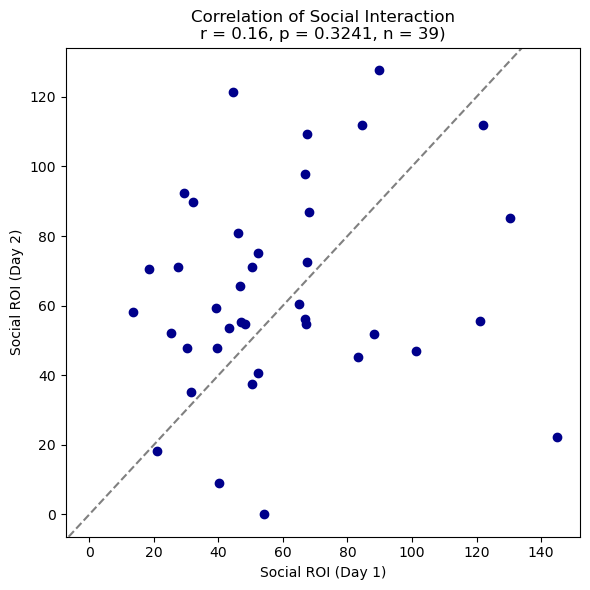

In [69]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# 1. Load Sheet2 from Excel
df = pd.read_excel(r"C:\Users\sjs93\OneDrive - University of Florida\SI_opto_1_2.xlsx", sheet_name=1)  # 1 = second sheet

# 2. Clean column names
df.columns = df.columns.str.strip().str.lower()

# 3. Rename for consistency
df = df.rename(columns={
    'animal': 'Subject_ID',
    'social agent roi': 'Social_ROI',
    'day': 'Day'
})

# 4. Drop rows missing critical info
df = df.dropna(subset=['Day', 'Subject_ID', 'Social_ROI'])

# 5. Pivot so each subject has a Day 1 and Day 2
pivot_df = df.pivot_table(index='Subject_ID', columns='Day', values='Social_ROI')

# 6. Rename columns for clarity
pivot_df = pivot_df.rename(columns={1: 'Social_ROI_Day1', 2: 'Social_ROI_Day2'})

# 7. Drop rows missing either day
pivot_df = pivot_df.dropna(subset=['Social_ROI_Day1', 'Social_ROI_Day2'])

# 8. Run correlation
r, p = pearsonr(pivot_df['Social_ROI_Day1'], pivot_df['Social_ROI_Day2'])
print(f"Pearson correlation: r = {r:.2f}, p = {p:.4f}, n = {len(pivot_df)}")

# 9. Plot
plt.figure(figsize=(6,6))
plt.scatter(pivot_df['Social_ROI_Day1'], pivot_df['Social_ROI_Day2'], color='darkblue')
plt.xlabel("Social ROI (Day 1)")
plt.ylabel("Social ROI (Day 2)")
plt.title(f"Correlation of Social Interaction\nr = {r:.2f}, p = {p:.4f}, n = {len(pivot_df)})")
plt.axline((0, 0), slope=1, linestyle='--', color='gray')
plt.tight_layout()
plt.show()


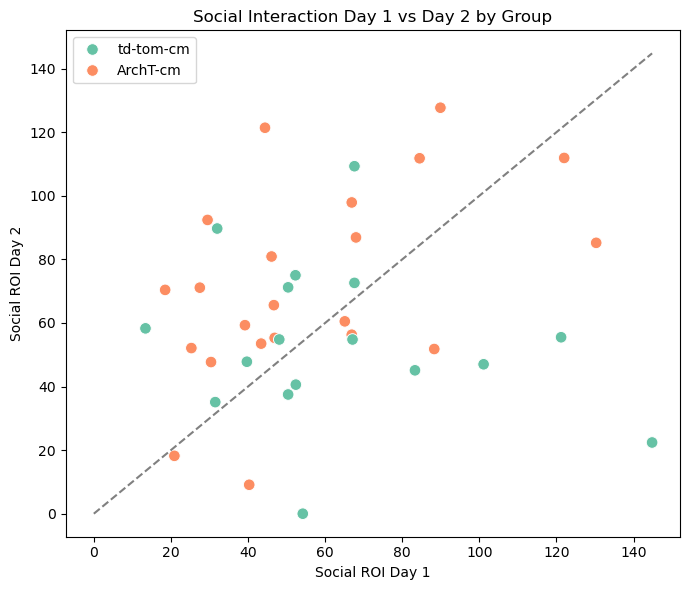

td-tom-cm: r = -0.21, p = 0.4248, n = 17
ArchT-cm: r = 0.49, p = 0.0200, n = 22


In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Load Excel file
df = pd.read_excel(r"C:\Users\sjs93\OneDrive - University of Florida\SI_opto_1_2.xlsx", sheet_name=1)

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Rename columns for clarity
df.rename(columns={
    'day': 'Day',
    'animal': 'Animal',
    'social_agent_roi': 'Social_ROI',
    'group': 'Group'
}, inplace=True)

# Create consistent subject ID
df['Subject_ID'] = df['Animal'].astype(str)

# Clean group labels (remove '-on', '-off' to keep only ArchT / tdTom)
df['Group'] = df['Group'].str.replace('-on', '', regex=False).str.replace('-off', '', regex=False)

# Pivot to get Social ROI for Day 1 and Day 2 per subject
pivot_df = df.pivot(index='Subject_ID', columns='Day', values='Social_ROI')
pivot_df.columns = ['Day1', 'Day2']
pivot_df = pivot_df.dropna()

# Add cleaned group info
group_info = df[['Subject_ID', 'Group']].drop_duplicates()
pivot_df = pivot_df.merge(group_info, on='Subject_ID')

# Plot Day 1 vs Day 2 with hue by Group
plt.figure(figsize=(7,6))
sns.scatterplot(data=pivot_df, x='Day1', y='Day2', hue='Group', palette='Set2', s=70)
sns.lineplot(x=[0, pivot_df[['Day1','Day2']].max().max()],
             y=[0, pivot_df[['Day1','Day2']].max().max()],
             color='gray', linestyle='--')
plt.xlabel("Social ROI Day 1")
plt.ylabel("Social ROI Day 2")
plt.title("Social Interaction Day 1 vs Day 2 by Group")
plt.tight_layout()
plt.show()

# Print correlation per group
for group in pivot_df['Group'].unique():
    sub = pivot_df[pivot_df['Group'] == group]
    r, p = pearsonr(sub['Day1'], sub['Day2'])
    print(f"{group}: r = {r:.2f}, p = {p:.4f}, n = {len(sub)}")


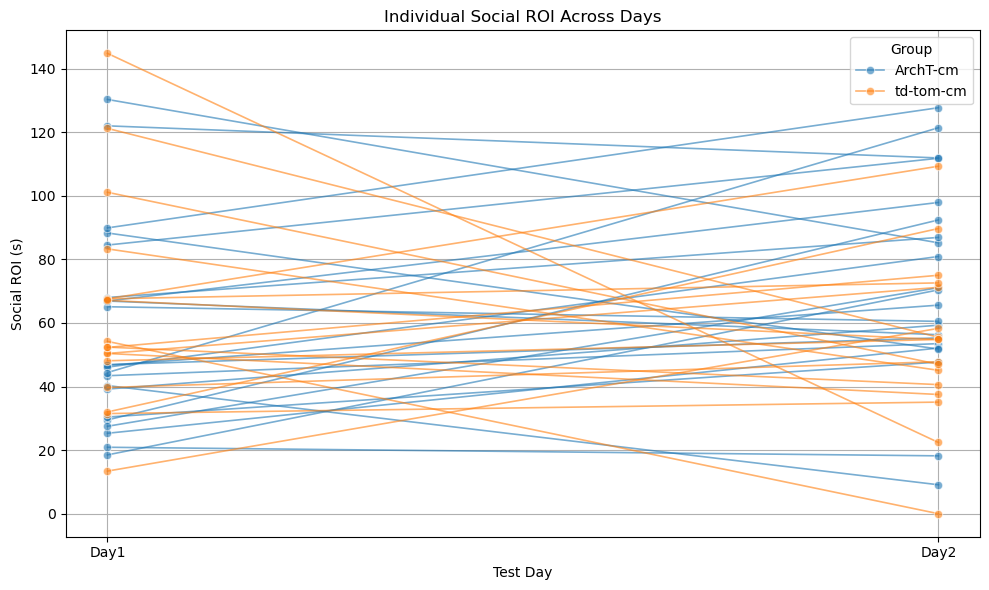

In [78]:
# Melt the pivot table for plotting
long_df = pivot_df.reset_index().melt(
    id_vars=['Subject_ID', 'Group'],
    value_vars=['Day1', 'Day2'],
    var_name='Day',
    value_name='Social_ROI'
)

# Sort by Subject_ID for consistent plotting
long_df = long_df.sort_values(by=['Group', 'Subject_ID'])

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=long_df,
    x='Day',
    y='Social_ROI',
    hue='Group',
    estimator=None,  # no mean line — just individual mouse lines
    units='Subject_ID',
    lw=1.2,
    alpha=0.6,
    marker='o'
)
plt.title('Individual Social ROI Across Days')
plt.ylabel('Social ROI (s)')
plt.xlabel('Test Day')
plt.grid(True)
plt.tight_layout()
plt.show()


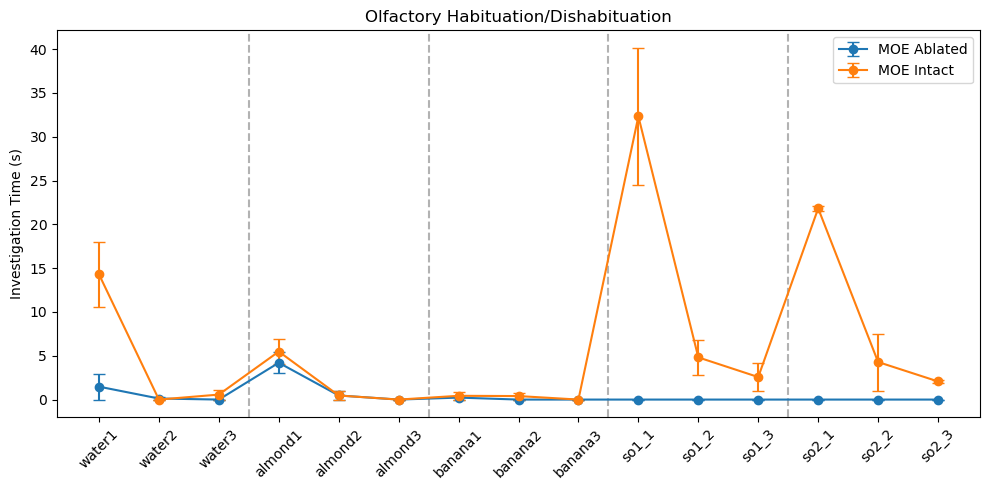

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Raw data dictionary
data = {
    "Trial": [
        "water1", "water2", "water3",
        "almond1", "almond2", "almond3",
        "banana1", "banana2", "banana3",
        "so1_1", "so1_2", "so1_3",
        "so2_1", "so2_2", "so2_3"
    ],
    "1.1": [0, 0, 0, 5.43, 0.94, 0, 0.45, 0, 0, 0, 0, 0, 0, 0, 0],
    "1.3": [18.04, 0, 1.14, 6.89, 0.93, 0, 0.86, 0, 0, 40.14, 6.82, 4.16, 21.51, 1.03, 2.25],
    "1.2": [2.95, 0.24, 0, 2.98, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "1.4": [10.55, 0, 0, 4.07, 0, 0, 0, 0.8, 0, 24.51, 2.81, 0.98, 22.14, 7.54, 1.89]
}

df = pd.DataFrame(data)

# Assign groups
moe_ablated = ["1.1", "1.2"]
moe_intact = ["1.3", "1.4"]

# Calculate means and SEMs
df["Ablated_mean"] = df[moe_ablated].mean(axis=1)
df["Ablated_sem"] = df[moe_ablated].sem(axis=1)

df["Intact_mean"] = df[moe_intact].mean(axis=1)
df["Intact_sem"] = df[moe_intact].sem(axis=1)

# X positions
x = np.arange(len(df))

# Plot
plt.figure(figsize=(10,5))
plt.errorbar(x, df["Ablated_mean"], yerr=df["Ablated_sem"], label="MOE Ablated", fmt='-o', capsize=4)
plt.errorbar(x, df["Intact_mean"], yerr=df["Intact_sem"], label="MOE Intact", fmt='-o', capsize=4)

# Add odor block separators
for pos in [3, 6, 9, 12]:
    plt.axvline(pos-0.5, color='gray', linestyle='--', alpha=0.6)

plt.xticks(x, df["Trial"], rotation=45)
plt.ylabel("Investigation Time (s)")
plt.title("Olfactory Habituation/Dishabituation")
plt.legend()
plt.tight_layout()
plt.show()


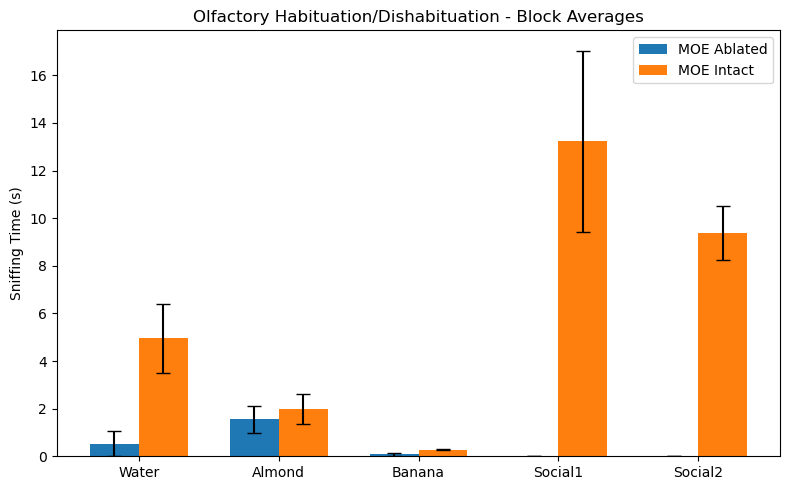

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Raw data
data = {
    "Trial": [
        "water1", "water2", "water3",
        "almond1", "almond2", "almond3",
        "banana1", "banana2", "banana3",
        "so1_1", "so1_2", "so1_3",
        "so2_1", "so2_2", "so2_3"
    ],
    "1.1": [0, 0, 0, 5.43, 0.94, 0, 0.45, 0, 0, 0, 0, 0, 0, 0, 0],
    "1.2": [2.95, 0.24, 0, 2.98, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "1.3": [18.04, 0, 1.14, 6.89, 0.93, 0, 0.86, 0, 0, 40.14, 6.82, 4.16, 21.51, 1.03, 2.25],
    "1.4": [10.55, 0, 0, 4.07, 0, 0, 0, 0.8, 0, 24.51, 2.81, 0.98, 22.14, 7.54, 1.89]
}

df = pd.DataFrame(data)

# Define groups
moe_ablated = ["1.1", "1.2"]
moe_intact = ["1.3", "1.4"]

# Define odor blocks
blocks = {
    "Water": [0, 1, 2],
    "Almond": [3, 4, 5],
    "Banana": [6, 7, 8],
    "Social1": [9, 10, 11],
    "Social2": [12, 13, 14]
}

# Compute mean per block per mouse
block_data = []
for block_name, idxs in blocks.items():
    row = {"Block": block_name}
    for mouse in moe_ablated + moe_intact:
        row[mouse] = df.loc[idxs, mouse].mean()
    block_data.append(row)

block_df = pd.DataFrame(block_data)

# Compute group means and SEM
block_df["Ablated_mean"] = block_df[moe_ablated].mean(axis=1)
block_df["Ablated_sem"] = block_df[moe_ablated].sem(axis=1)

block_df["Intact_mean"] = block_df[moe_intact].mean(axis=1)
block_df["Intact_sem"] = block_df[moe_intact].sem(axis=1)

# Plot
x = np.arange(len(block_df))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, block_df["Ablated_mean"], width, yerr=block_df["Ablated_sem"],
        label="MOE Ablated", capsize=5)
plt.bar(x + width/2, block_df["Intact_mean"], width, yerr=block_df["Intact_sem"],
        label="MOE Intact", capsize=5)

plt.xticks(x, block_df["Block"])
plt.ylabel("Sniffing Time (s)")
plt.title("Olfactory Habituation/Dishabituation - Block Averages")
plt.legend()
plt.tight_layout()
plt.show()


In [79]:
from scipy.stats import ttest_rel

# Loop over groups
for group in pivot_df['Group'].unique():
    sub = pivot_df[pivot_df['Group'] == group]
    t_stat, p_val = ttest_rel(sub['Day1'], sub['Day2'])
    mean1 = sub['Day1'].mean()
    mean2 = sub['Day2'].mean()
    print(f"{group}: Day1 mean = {mean1:.2f}, Day2 mean = {mean2:.2f}")
    print(f"  Paired t-test: t = {t_stat:.2f}, p = {p_val:.4f}, n = {len(sub)}\n")


td-tom-cm: Day1 mean = 63.36, Day2 mean = 53.92
  Paired t-test: t = 0.85, p = 0.4094, n = 17

ArchT-cm: Day1 mean = 56.41, Day2 mean = 72.14
  Paired t-test: t = -2.37, p = 0.0272, n = 22



In [80]:
from scipy.stats import ttest_rel

# Run paired t-test on all mice
t_stat, p_val = ttest_rel(pivot_df['Day1'], pivot_df['Day2'])

# Print results
mean1 = pivot_df['Day1'].mean()
mean2 = pivot_df['Day2'].mean()
print(f"All mice combined:")
print(f"  Day 1 mean = {mean1:.2f}, Day 2 mean = {mean2:.2f}")
print(f"  Paired t-test: t = {t_stat:.2f}, p = {p_val:.4f}, n = {len(pivot_df)}")


All mice combined:
  Day 1 mean = 59.44, Day 2 mean = 64.20
  Paired t-test: t = -0.75, p = 0.4595, n = 39


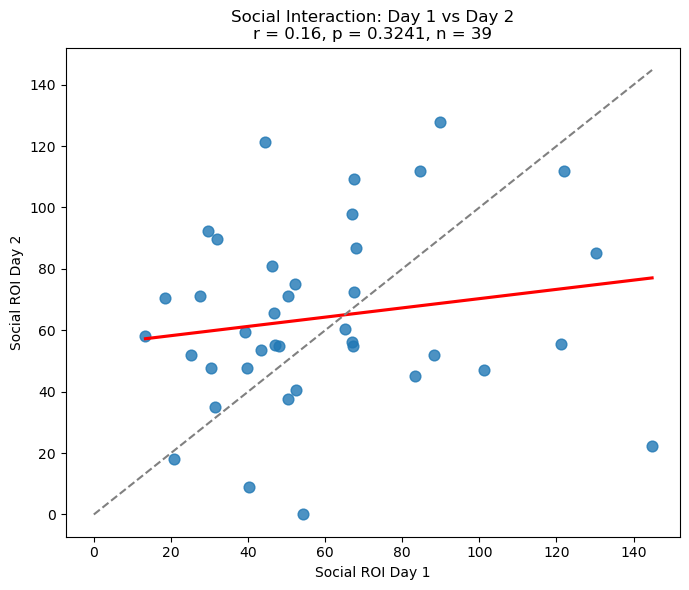

r = 0.16, p = 0.3241, n = 39


In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Load data
df = pd.read_excel(r"C:\Users\sjs93\OneDrive - University of Florida\SI_opto_1_2.xlsx", sheet_name=1)

# 2. Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 3. Rename for clarity
df.rename(columns={
    'day': 'Day',
    'animal': 'Animal',
    'social_agent_roi': 'Social_ROI'
}, inplace=True)

# 4. Create subject ID (cage.mouse_id)
df['Subject_ID'] = df['Animal'].astype(str)

# 5. Pivot to get Day 1 and Day 2 ROI per subject
pivot_df = df.pivot(index='Subject_ID', columns='Day', values='Social_ROI')
pivot_df.columns = ['Day1', 'Day2']
pivot_df = pivot_df.dropna()

# 6. Correlation
r, p = pearsonr(pivot_df['Day1'], pivot_df['Day2'])

# 7. Plot
plt.figure(figsize=(7,6))
sns.regplot(data=pivot_df, x='Day1', y='Day2', ci=None, scatter_kws={'s': 60, 'alpha': 0.8}, line_kws={'color': 'red'})
plt.plot([0, pivot_df[['Day1','Day2']].max().max()], [0, pivot_df[['Day1','Day2']].max().max()], linestyle='--', color='gray')
plt.xlabel("Social ROI Day 1")
plt.ylabel("Social ROI Day 2")
plt.title(f"Social Interaction: Day 1 vs Day 2\nr = {r:.2f}, p = {p:.4f}, n = {len(pivot_df)}")
plt.tight_layout()
plt.show()

# 8. Print stats
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(pivot_df)}")


In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Load your data sheet2
df = pd.read_excel(r"C:\Users\sjs93\OneDrive - University of Florida\SI_opto_1_2.xlsx", sheet_name=1)

# Clean columns
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Rename for clarity
df.rename(columns={
    'day': 'Day',
    'animal': 'Animal',
    'social_agent_roi': 'Social_ROI',
    'group': 'Group'  # if it exists; else use treatment column
}, inplace=True)

# If 'group' column doesn't exist, use 'treatment' instead
if 'group' not in df.columns and 'treatment' in df.columns:
    df['Group'] = df['treatment']
else:
    df['Group'] = df['group']

# Create subject ID
df['Subject_ID'] = df['animal'].astype(str)

# Pivot for day 1 and day 2
pivot_df = df.pivot(index='Subject_ID', columns='Day', values='Social_ROI')
pivot_df.columns = ['Day1', 'Day2']
pivot_df = pivot_df.dropna()

# Get group info
group_info = df[['Subject_ID', 'Group']].drop_duplicates()
pivot_df = pivot_df.merge(group_info, on='Subject_ID')

# Optional: simplify group names for plotting
def simplify_group(name):
    if 'td-tom' in name.lower():
        return 'Control (td-tom)'
    elif 'archt' in name.lower():
        return 'ArchT'
    else:
        return 'Other'

pivot_df['Group_simple'] = pivot_df['Group'].apply(simplify_group)

# Plot
plt.figure(figsize=(7,6))
sns.scatterplot(data=pivot_df, x='Day1', y='Day2', hue='Group_simple', palette='Set1', s=70)
plt.plot([0, pivot_df[['Day1','Day2']].max().max()], [0, pivot_df[['Day1','Day2']].max().max()], 'k--')
plt.xlabel("Social ROI Day 1 (s)")
plt.ylabel("Social ROI Day 2 (s)")
plt.title("Social Interaction Day 1 vs Day 2 by Group")
plt.legend(title='Group')
plt.tight_layout()
plt.show()

# Correlations by group
for group in pivot_df['Group_simple'].unique():
    sub = pivot_df[pivot_df['Group_simple'] == group]
    r, p = pearsonr(sub['Day1'], sub['Day2'])
    print(f"{group}: Pearson r = {r:.2f}, p = {p:.4f}, n = {len(sub)}")


KeyError: 'group'

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Load your data sheet2
df = pd.read_excel(r"C:\Users\sjs93\OneDrive - University of Florida\SI_opto_1_2.xlsx", sheet_name=1)

# Clean columns
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Rename for clarity
df.rename(columns={
    'day': 'Day',
    'animal': 'Animal',
    'social_agent_roi': 'Social_ROI',
}, inplace=True)

# Assign 'Group' column properly
if 'group' in df.columns:
    df['Group'] = df['group']
elif 'treatment' in df.columns:
    df['Group'] = df['treatment']
else:
    raise ValueError("Neither 'group' nor 'treatment' columns found.")

# Create subject ID
df['Subject_ID'] = df['animal'].astype(str)

# Pivot for day 1 and day 2 social ROI
pivot_df = df.pivot(index='Subject_ID', columns='Day', values='Social_ROI')
pivot_df.columns = ['Day1', 'Day2']
pivot_df = pivot_df.dropna()

# Get group info
group_info = df[['Subject_ID', 'Group']].drop_duplicates()
pivot_df = pivot_df.merge(group_info, on='Subject_ID')

# Simplify group names for plotting
def simplify_group(name):
    if 'td-tom' in name.lower():
        return 'Control (td-tom)'
    elif 'archt' in name.lower():
        return 'ArchT'
    else:
        return 'Other'

pivot_df['Group_simple'] = pivot_df['Group'].apply(simplify_group)

# Plot
plt.figure(figsize=(7,6))
sns.scatterplot(data=pivot_df, x='Day1', y='Day2', hue='Group_simple', palette='Set1', s=70)
plt.plot([0, pivot_df[['Day1','Day2']].max().max()], [0, pivot_df[['Day1','Day2']].max().max()], 'k--')
plt.xlabel("Social ROI Day 1 (s)")
plt.ylabel("Social ROI Day 2 (s)")
plt.title("Social Interaction Day 1 vs Day 2 by Group")
plt.legend(title='Group')
plt.tight_layout()
plt.show()

# Correlations by group
for group in pivot_df['Group_simple'].unique():
    sub = pivot_df[pivot_df['Group_simple'] == group]
    r, p = pearsonr(sub['Day1'], sub['Day2'])
    print(f"{group}: Pearson r = {r:.2f}, p = {p:.4f}, n = {len(sub)}")


KeyError: 'animal'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Load Excel file (Sheet 2)
file_path = r"C:\Users\sjs93\OneDrive - University of Florida\SI_opto_1_2.xlsx"
df = pd.read_excel(file_path, sheet_name=1)

# 2. Clean column names
df.columns = df.columns.str.strip().str.lower()

# 3. Rename to standard column names if needed
df = df.rename(columns={
    'day': 'day',
    'animal': 'subject_id',
    'social agent roi': 'social_roi'
})

# 4. Drop rows missing relevant info
df = df.dropna(subset=['day', 'subject_id', 'social_roi'])

# 5. Pivot table to align Day 1 and Day 2 values per subject
pivot_df = df.pivot_table(index='subject_id', columns='day', values='social_roi')

# 6. Rename columns for clarity
pivot_df = pivot_df.rename(columns={1: 'social_roi_day1', 2: 'social_roi_day2'})

# 7. Drop rows missing either day
pivot_df = pivot_df.dropna(subset=['social_roi_day1', 'social_roi_day2'])

# 8. Run correlation
r, p = pearsonr(pivot_df['social_roi_day1'], pivot_df['social_roi_day2'])

# 9. Plot the results
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['social_roi_day1'], pivot_df['social_roi_day2'], color='darkblue')
plt.xlabel("Social ROI (Day 1)")
plt.ylabel("Social ROI (Day 2)")
plt.title(f"Within-Subject Correlation (n={len(pivot_df)})\nr = {r:.2f}, p = {p:.4f}")
plt.axline((0, 0), slope=1, linestyle='--', color='gray')
plt.tight_layout()
plt.show()

# 10. Print correlation stats
print(f"n = {len(pivot_df)}, r = {r:.3f}, p = {p:.4f}")
